In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import transforms

sys.path.append(os.path.abspath(os.path.join("../..")))
from src.models.convoluationaltransformer.convtrans_v1 import Captcha_Convolutional_Transformer_V1
from src.datasets.huggingfacefilelistdataset import HuggingFaceFileListDataset

In [3]:
captcha_transformation = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((40, 150)),
        transforms.ToTensor(),
    ]
)
dataset = HuggingFaceFileListDataset(
    file_list="/nfs/home/tpz8688/Captcha-Recognition/notebooks/data-cleaning/clean_images_v2.txt", 
    transform=captcha_transformation
)

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Captcha_Convolutional_Transformer_V1(num_chars=len(dataset.vocab) + 1)
state_dict = torch.load(Captcha_Convolutional_Transformer_V1.SAVE_DIR / "v4.pth", map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print(f"Model successfully loaded from {Captcha_Convolutional_Transformer_V1.SAVE_DIR / "v4.pth"}")

Model successfully loaded from /nfs/home/tpz8688/Captcha-Recognition/weights/conv_transformer/v4.pth


In [39]:
attention_weights = {}

def get_attention_hook(name):
    def hook(module, input, output):
        # index [1] contains the weights (Batch, 35, 35)
        # index [0] is the feature activations (Batch, 35, 1280)
        if len(output) > 1 and output[1] is not None:
            attention_weights[name] = output[1].detach().cpu()
        else:
            # If output[1] is None, the layer was called with need_weights=False
            print(f"Warning: Weights not found in {name}. Ensure need_weights=True.")
            
    return hook

# Register the hook as you did before
layer_to_monitor = model.transformer.layers[0].self_attn
layer_to_monitor.register_forward_hook(get_attention_hook("layer_0_attn"))

In [40]:
layer_to_monitor = model.transformer.layers[0].self_attn
layer_to_monitor.register_forward_hook(get_attention_hook("layer_0_attn"))

In [57]:
image, label, length = dataset[150]
input_tensor = image.unsqueeze(0).to(device)

In [58]:
# Manually extract the square matrix if the hook returns None
with torch.no_grad():
    # Get the features right before the transformer
    # (Replicating your model's forward logic)
    x = model.conv(input_tensor)
    x = x.permute(0, 3, 1, 2)
    b, t, c, h = x.size()
    x = x.reshape(b, t, c * h)
    x = model.positional_encoding(x)
    
    # Manually trigger the attention layer with weights enabled
    attn_layer = model.transformer.layers[0].self_attn
    # Returns (output, weights)
    _, weights = attn_layer(x, x, x, need_weights=True, average_attn_weights=True)
    
    attn_map = weights[0].cpu().numpy() # This will be (35, 35)

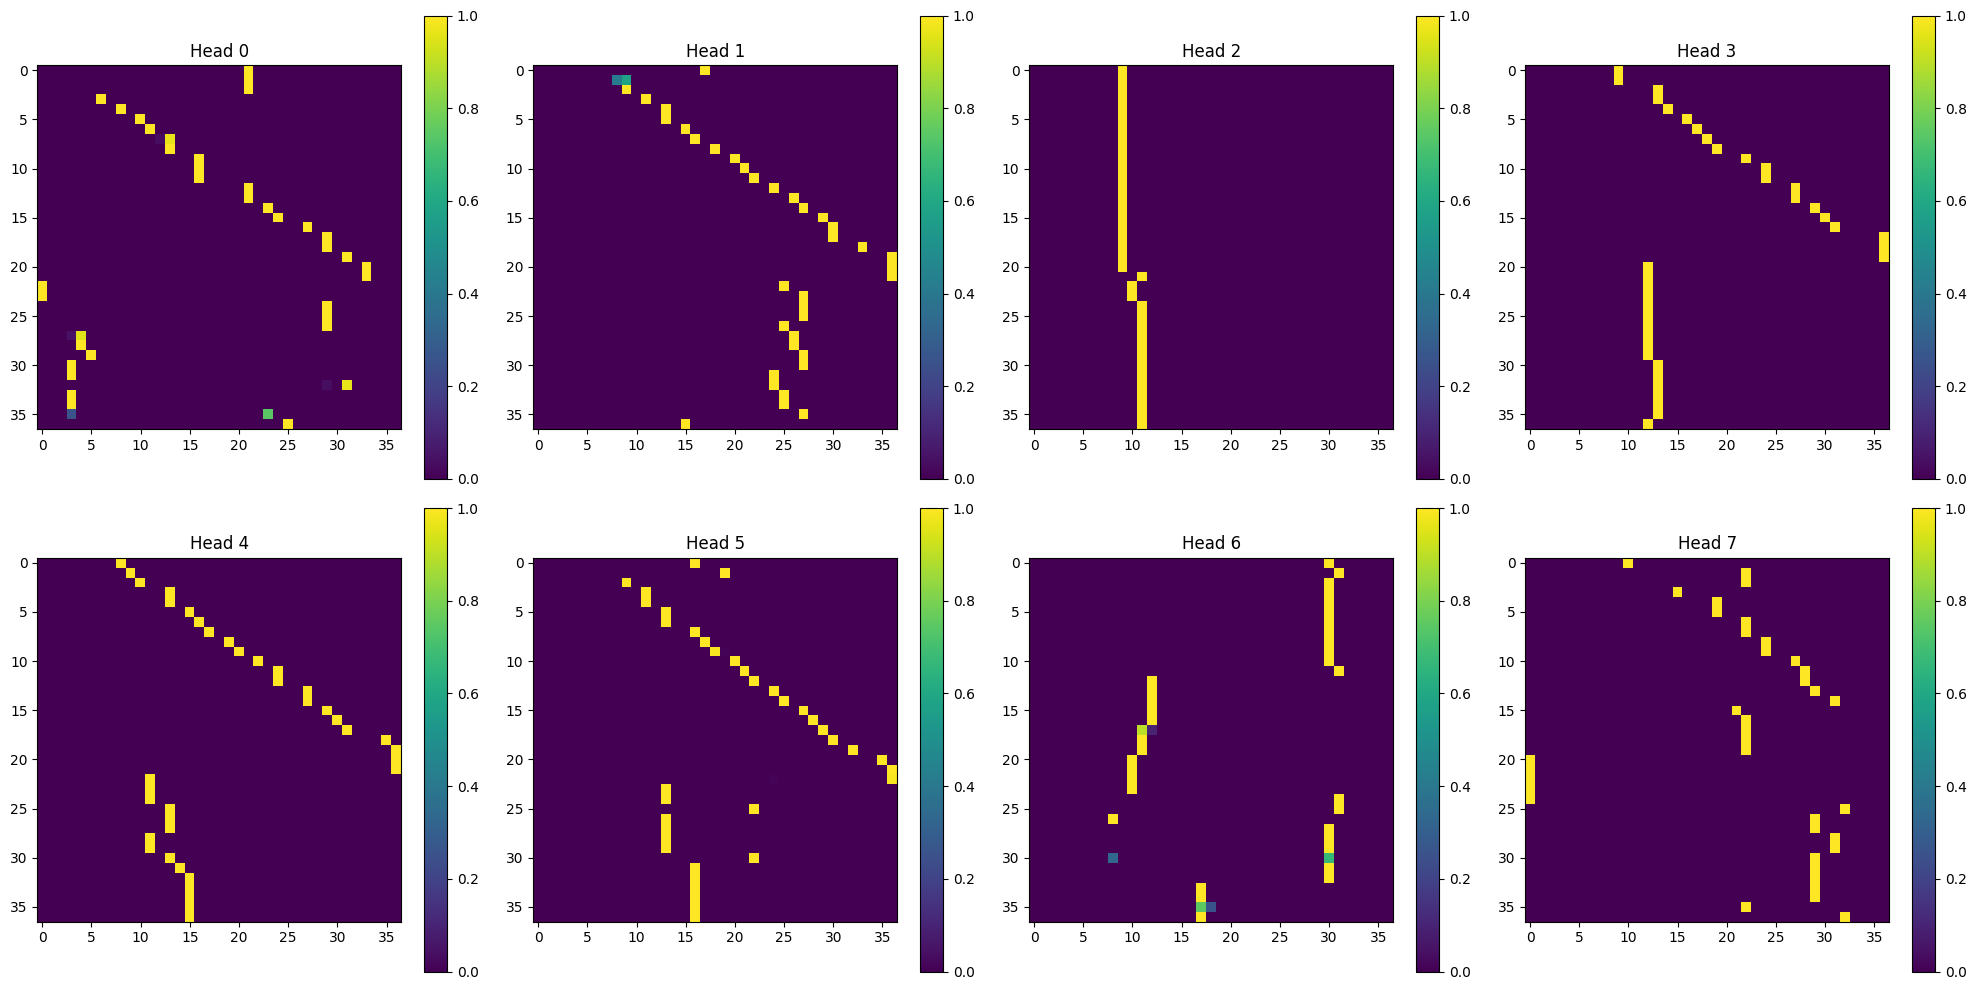

In [60]:
def get_per_head_attention(model, input_tensor):
    # 1. Manually get the features right before the transformer
    x = model.conv(input_tensor)
    x = x.permute(0, 3, 1, 2)
    b, t, c, h = x.size()
    x = x.reshape(b, t, c * h)
    x = model.positional_encoding(x)
    
    # 2. Access the attention layer
    # We use the internal weights but set average_attn_weights=False
    attn_module = model.transformer.layers[0].self_attn
    
    # query, key, value are all 'x' for self-attention
    _, weights = attn_module(x, x, x, 
                             need_weights=True, 
                             average_attn_weights=False)
    
    # Output shape: (Batch, Num_Heads, Seq_Len, Seq_Len) -> (1, 8, 35, 35)
    return weights[0].detach().cpu()

# Get the 8 matrices
all_heads = get_per_head_attention(model, input_tensor)

# Visualize them in a grid
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i in range(8):
    ax = axes[i//4, i%4]
    im = ax.imshow(all_heads[i], cmap='viridis')
    ax.set_title(f"Head {i}")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

Spatial Alignment and Sequential Processing (Heads 0, 1, 3, 4, 5)
These "Scanner" heads are characterized by a strong, crisp diagonal line, indicating that the model is maintaining a direct spatial mapping between the CNN-extracted features and the output sequence. This behavior ensures that the Transformer preserves the horizontal order of characters, effectively "scanning" the CAPTCHA from left to right. By focusing primarily on local information at each timestep, these heads prevent the spatial scrambling of characters and provide the structural backbone for the recognition task.

Global Landmarks and Environmental Calibration (Heads 2, 6)
In contrast to the scanning heads, these "Anchor" heads exhibit prominent vertical stripes at specific horizontal indices (e.g., Key positions 10 and 30). This pattern reveals that regardless of which character is being predicted, the model consistently "consults" these specific regions to gather context. These landmarks often represent fixed image properties, such as background noise patterns, vertical strike-through lines, or consistent whitespace gaps, which the model uses as reference points to calibrate its understanding of the overall image layout.

Relational Context and Feature Correlation (Heads 0, 7)
The more fragmented and "spotty" patterns in these heads suggest they are responsible for identifying non-linear relationships and global dependencies across the entire image. Head 7, for instance, shows activity that links distant timesteps, likely performing consistency checks between the beginning and end of the string to ensure linguistic or structural coherence. These heads allow the model to move beyond simple local scanning, using the Transformer's global attention capacity to resolve ambiguities where characters might overlap or be distorted by heavy noise.